In [1]:
# step 1 is Importing  libraries and load the data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  step 2 have to load the dataset that is just created in the other saved folder called "namibia_crid_date"
df = pd.read_csv('namibia_crime_data.csv')

# step 3 this are things to look for basic info 
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (7280, 6)

First 5 rows:
   Year  Month        Date  Region       CrimeType  CrimeCount
0  2020      1  2020-01-01  Khomas           Theft         154
1  2020      1  2020-01-01  Khomas         Assault         126
2  2020      1  2020-01-01  Khomas         Robbery          56
3  2020      1  2020-01-01  Khomas  Sexual Offence          41
4  2020      1  2020-01-01  Khomas   Housebreaking         117

Data types:
Year           int64
Month          int64
Date          object
Region        object
CrimeType     object
CrimeCount     int64
dtype: object

Missing values:
Year          0
Month         0
Date          0
Region        0
CrimeType     0
CrimeCount    0
dtype: int64


In [2]:
# Step 4 the summary statistics
print("Summary statistics for CrimeCount:")
print(df['CrimeCount'].describe())
print("\nTotal crime incidents:", df['CrimeCount'].sum())
print("Number of regions:", df['Region'].nunique())
print("Number of crime types:", df['CrimeType'].nunique())
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Summary statistics for CrimeCount:
count    7280.000000
mean       49.184753
std        38.705894
min         2.000000
25%        22.000000
50%        38.000000
75%        62.000000
max       249.000000
Name: CrimeCount, dtype: float64

Total crime incidents: 358065
Number of regions: 14
Number of crime types: 8
Date range: 2020-01-01 to 2025-05-01


Total crime by region:
Region
Erongo          42981
Kavango East    42885
Ohangwena       42750
Oshana          42640
Khomas          42618
Otjozondjupa    16254
Kavango West    16126
Kunene          16109
Hardap          16089
Oshikoto        16042
Omaheke         15989
ǁKaras          15926
Omusati         15841
Zambezi         15815
Name: CrimeCount, dtype: int64


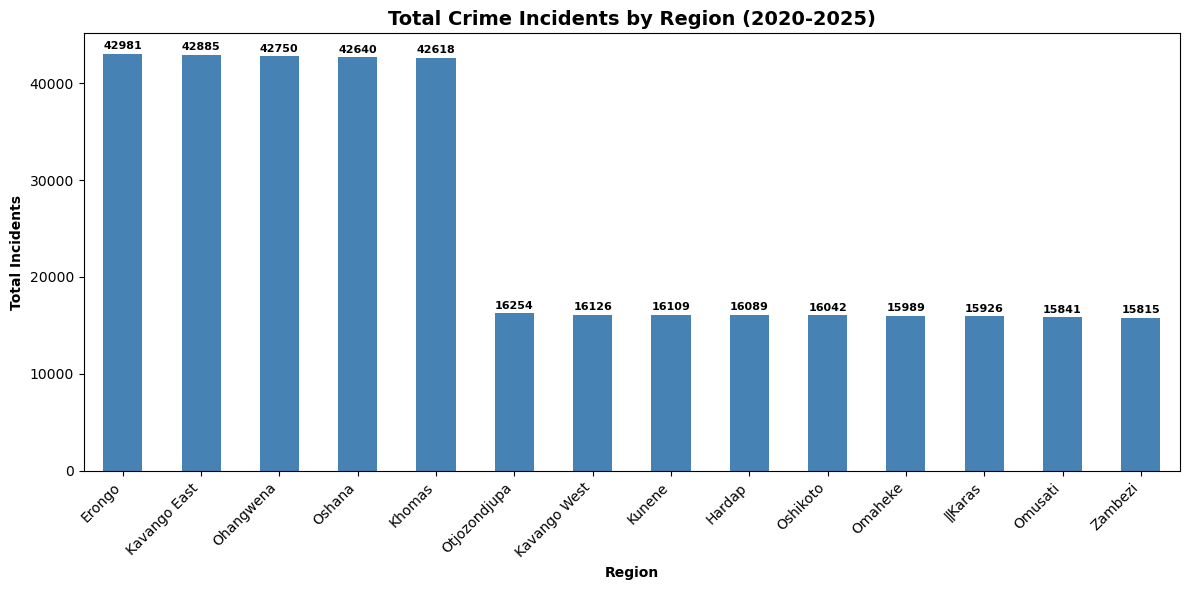

In [10]:
# step 5 the total crime by region (bar chart)
region_total = df.groupby('Region')['CrimeCount'].sum().sort_values(ascending=False)
print("Total crime by region:")
print(region_total)

plt.figure(figsize=(12,6))
region_total.plot(kind='bar', color='steelblue')
ax = region_total.plot(kind='bar', color='steelblue')
ax.bar_label(ax.containers[0], fontsize=8, padding=2, fontweight = 'bold')
plt.title('Total Crime Incidents by Region (2020-2025)', fontsize=14, fontweight = 'bold')
plt.xlabel('Region', fontweight = 'bold')
plt.ylabel('Total Incidents', fontweight = 'bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('crime_by_region.png')
plt.show()

Total crime by type:
CrimeType
Theft             87741
Assault           65617
Housebreaking     58651
Drug Related      43858
Robbery           36744
Fraud             29164
Sexual Offence    21729
Car Theft         14561
Name: CrimeCount, dtype: int64


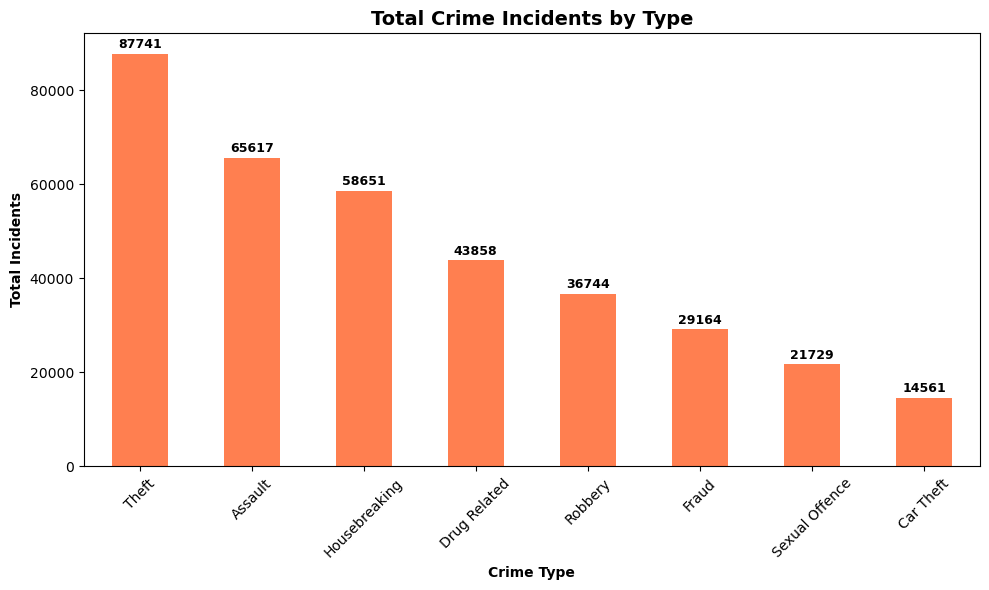

In [12]:
# step 6 the total crime by crime type
crime_total = df.groupby('CrimeType')['CrimeCount'].sum().sort_values(ascending=False)
print("Total crime by type:")
print(crime_total)

plt.figure(figsize=(10,6))
crime_total.plot(kind='bar', color='coral')
ax = crime_total.plot(kind='bar', color='coral')
ax.bar_label(ax.containers[0], fontsize=9, padding=2, fontweight = 'bold')
plt.title('Total Crime Incidents by Type', fontsize=14, fontweight = 'bold')
plt.xlabel('Crime Type', fontweight = 'bold')
plt.ylabel('Total Incidents', fontweight = 'bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crime_by_type.png')
plt.show()

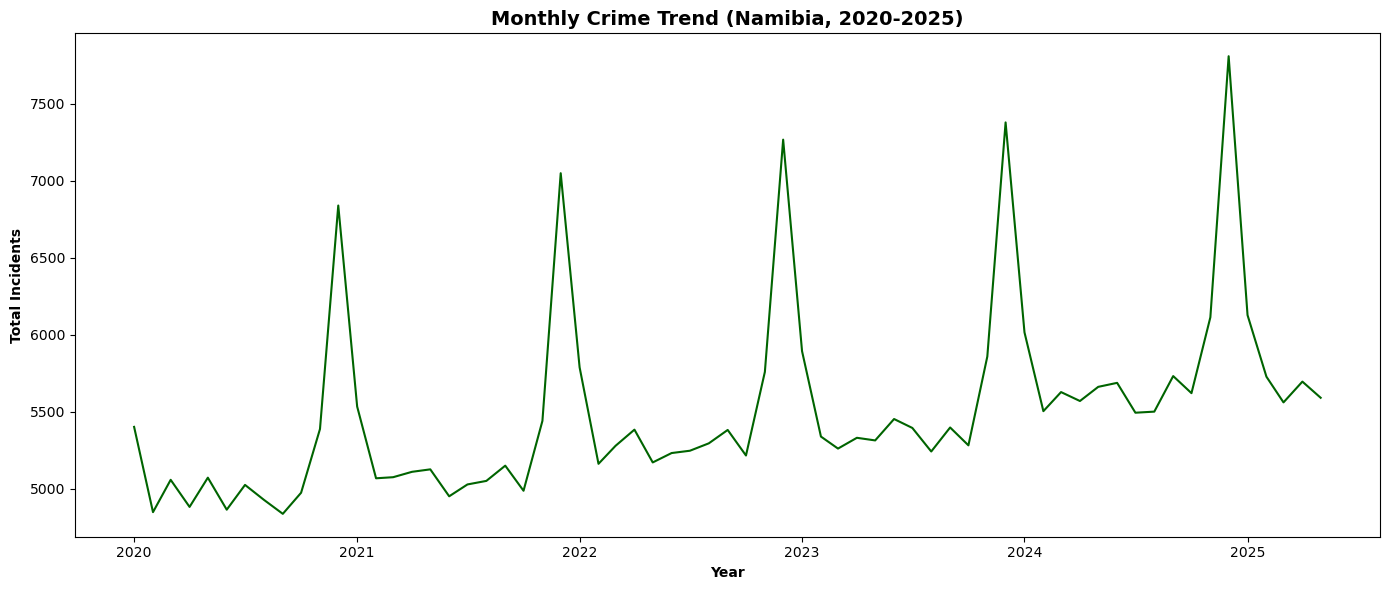

In [16]:
# step 7 now looking at the trend over time monthly
monthly_trend = df.groupby('Date')['CrimeCount'].sum().reset_index()
monthly_trend['Date'] = pd.to_datetime(monthly_trend['Date'])

plt.figure(figsize=(14,6))
plt.plot(monthly_trend['Date'], monthly_trend['CrimeCount'], linewidth=1.5, color='darkgreen')
plt.title('Monthly Crime Trend (Namibia, 2020-2025)', fontsize=14, fontweight = 'bold')
plt.xlabel('Year', fontweight = 'bold')
plt.ylabel('Total Incidents', fontweight = 'bold')
plt.tight_layout()
plt.savefig('crime_monthly_trend.png')
plt.show()

Urban vs Rural total crime:
RegionType
Rural    144191
Urban    213874
Name: CrimeCount, dtype: int64


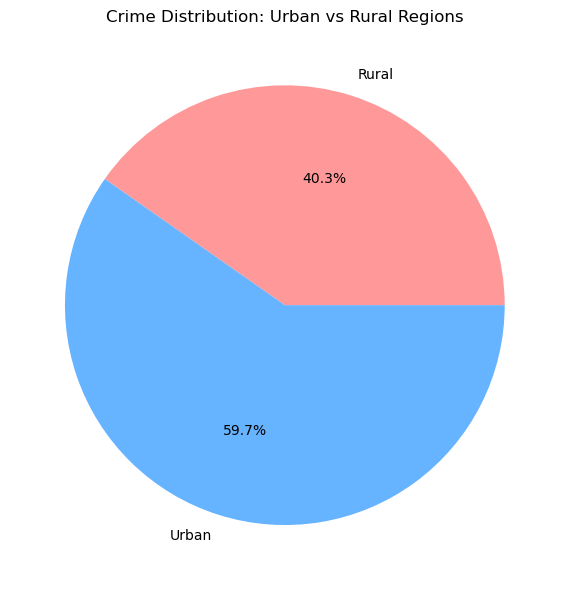

In [17]:
# step 8 Comparing urban vs rural regions
urban_regions = ['Khomas', 'Erongo', 'Oshana', 'Kavango East', 'Ohangwena']
df['RegionType'] = df['Region'].apply(lambda x: 'Urban' if x in urban_regions else 'Rural')

urban_rural_total = df.groupby('RegionType')['CrimeCount'].sum()
print("Urban vs Rural total crime:")
print(urban_rural_total)

plt.figure(figsize=(6,6))
urban_rural_total.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Crime Distribution: Urban vs Rural Regions')
plt.ylabel('')
plt.tight_layout()
plt.savefig('urban_rural_pie.png')
plt.show()

Top 3 crime types in Urban areas:
CrimeType
Theft            52255
Assault          39212
Housebreaking    35015
Name: CrimeCount, dtype: int64

Top 3 crime types in Rural areas:
CrimeType
Theft            35486
Assault          26405
Housebreaking    23636
Name: CrimeCount, dtype: int64


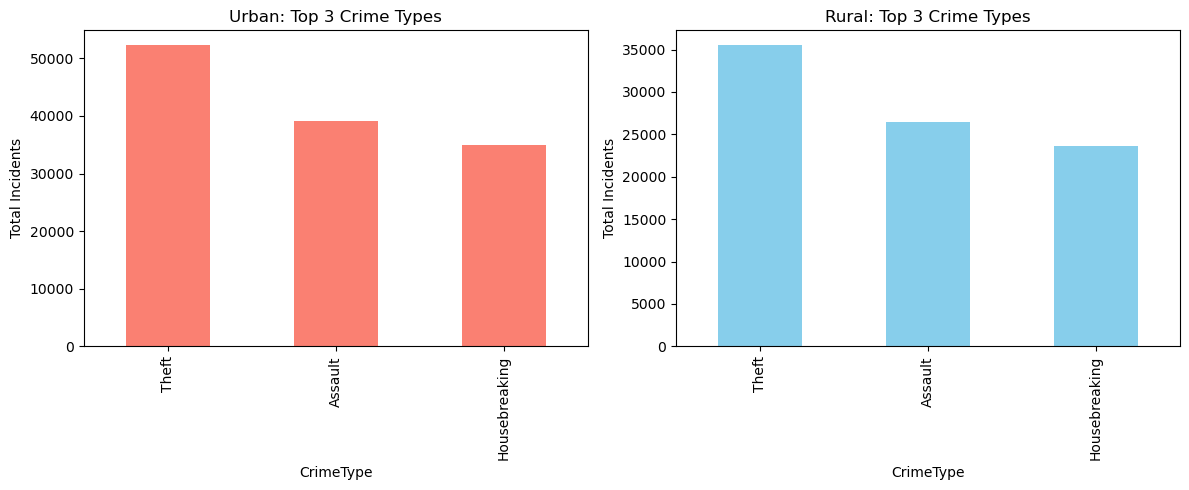

In [18]:
# Cell 7: Top 3 crime types in urban vs rural
urban_df = df[df['RegionType'] == 'Urban']
rural_df = df[df['RegionType'] == 'Rural']

urban_top = urban_df.groupby('CrimeType')['CrimeCount'].sum().sort_values(ascending=False).head(3)
rural_top = rural_df.groupby('CrimeType')['CrimeCount'].sum().sort_values(ascending=False).head(3)

print("Top 3 crime types in Urban areas:")
print(urban_top)
print("\nTop 3 crime types in Rural areas:")
print(rural_top)

# Bar chart comparing top 3
fig, axes = plt.subplots(1,2, figsize=(12,5))
urban_top.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Urban: Top 3 Crime Types')
axes[0].set_ylabel('Total Incidents')
rural_top.plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Rural: Top 3 Crime Types')
axes[1].set_ylabel('Total Incidents')
plt.tight_layout()
plt.savefig('urban_rural_top_crimes.png')
plt.show()

In [19]:
# Define urban regions (matching your simulation)
urban_regions = ['Khomas', 'Erongo', 'Oshana', 'Kavango East', 'Ohangwena']

# Create RegionType column if not already present
df['RegionType'] = df['Region'].apply(lambda x: 'Urban' if x in urban_regions else 'Rural')

# Top 5 crime types
top5_crimes = df.groupby('CrimeType')['CrimeCount'].sum().sort_values(ascending=False).head(5).index

# For each top crime, show urban vs rural breakdown
print("Top 5 crimes – urban vs rural comparison:\n")
for crime in top5_crimes:
    crime_df = df[df['CrimeType'] == crime]
    urban_rural_sum = crime_df.groupby('RegionType')['CrimeCount'].sum()
    
    # Calculate percentages
    total = urban_rural_sum.sum()
    urban_pct = (urban_rural_sum.get('Urban', 0) / total) * 100
    rural_pct = (urban_rural_sum.get('Rural', 0) / total) * 100
    
    print(f"Crime: {crime}")
    print(f"  Urban: {urban_rural_sum.get('Urban', 0):,} incidents ({urban_pct:.1f}%)")
    print(f"  Rural: {urban_rural_sum.get('Rural', 0):,} incidents ({rural_pct:.1f}%)")
    print()

Top 5 crimes – urban vs rural comparison:

Crime: Theft
  Urban: 52,255 incidents (59.6%)
  Rural: 35,486 incidents (40.4%)

Crime: Assault
  Urban: 39,212 incidents (59.8%)
  Rural: 26,405 incidents (40.2%)

Crime: Housebreaking
  Urban: 35,015 incidents (59.7%)
  Rural: 23,636 incidents (40.3%)

Crime: Drug Related
  Urban: 26,370 incidents (60.1%)
  Rural: 17,488 incidents (39.9%)

Crime: Robbery
  Urban: 21,924 incidents (59.7%)
  Rural: 14,820 incidents (40.3%)



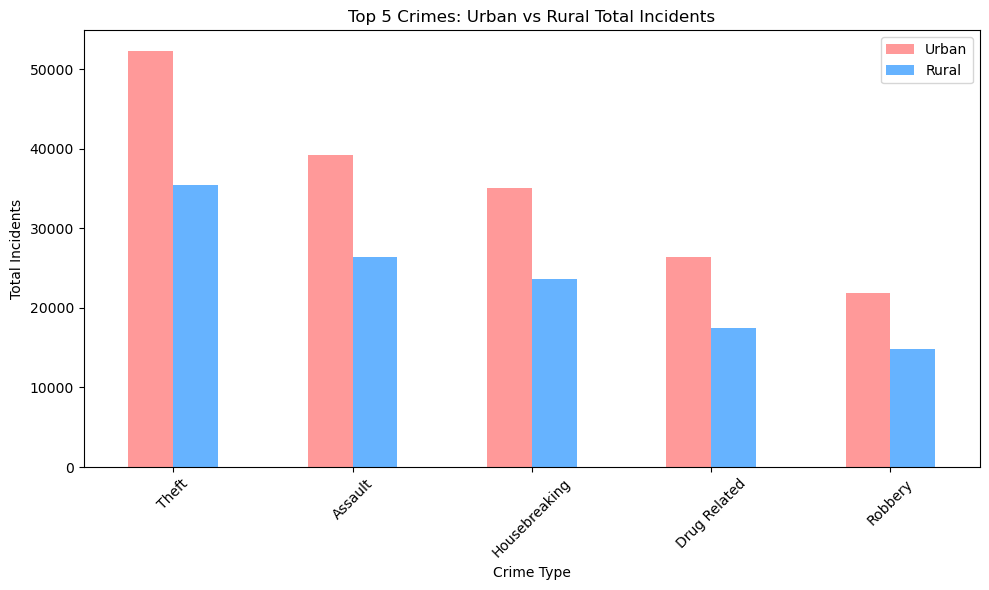

In [22]:
# Bar chart: top 5 crimes – urban vs rural
import matplotlib.pyplot as plt

# Prepare data for plotting
plot_data = []
for crime in top5_crimes:
    crime_df = df[df['CrimeType'] == crime]
    urban_rural = crime_df.groupby('RegionType')['CrimeCount'].sum()
    plot_data.append([urban_rural.get('Urban', 0), urban_rural.get('Rural', 0)])

plot_df = pd.DataFrame(plot_data, index=top5_crimes, columns=['Urban', 'Rural'])
ax.bar_label(ax.containers[0], fontsize=9, padding=2, fontweight = 'bold')
plt.title('Top 5 Crimes: Urban vs Rural Total Incidents')
plt.xlabel('Crime Type')
plt.ylabel('Total Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top5_crimes_urban_rural.png')
plt.show()

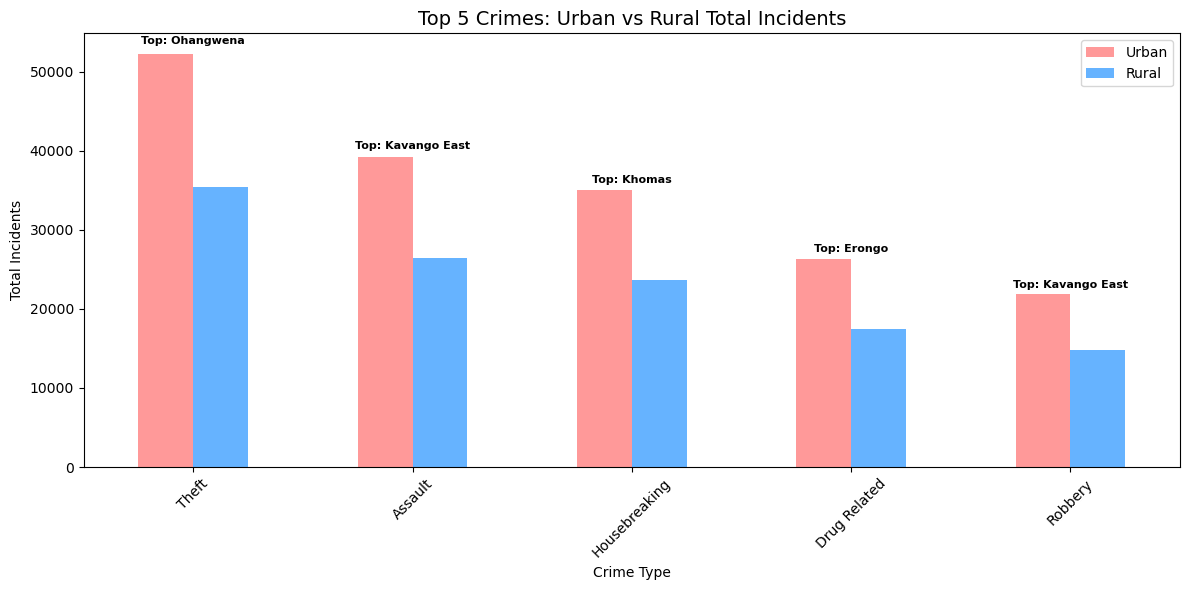

In [23]:
# After creating the urban/rural grouped bar chart (plot_df)
# First, get the top region for each crime
top_region_for_crime = {}
for crime in top5_crimes:
    crime_df = df[df['CrimeType'] == crime]
    region_sum = crime_df.groupby('Region')['CrimeCount'].sum()
    top_region = region_sum.idxmax()
    top_region_for_crime[crime] = top_region

# Create the same bar chart
ax = plot_df.plot(kind='bar', figsize=(12,6), color=['#ff9999','#66b3ff'])
plt.title('Top 5 Crimes: Urban vs Rural Total Incidents', fontsize=14)
plt.xlabel('Crime Type')
plt.ylabel('Total Incidents')
plt.xticks(rotation=45)

# Annotate each crime with its top region (place above the higher bar)
for i, crime in enumerate(top5_crimes):
    urban_val = plot_df.loc[crime, 'Urban']
    rural_val = plot_df.loc[crime, 'Rural']
    max_height = max(urban_val, rural_val)
    region_name = top_region_for_crime[crime]
    plt.text(i, max_height + (max_height * 0.02), 
             f"Top: {region_name}", 
             ha='center', va='bottom', fontsize=8, weight='bold')

plt.tight_layout()
plt.savefig('top5_crimes_with_top_region.png')
plt.show()

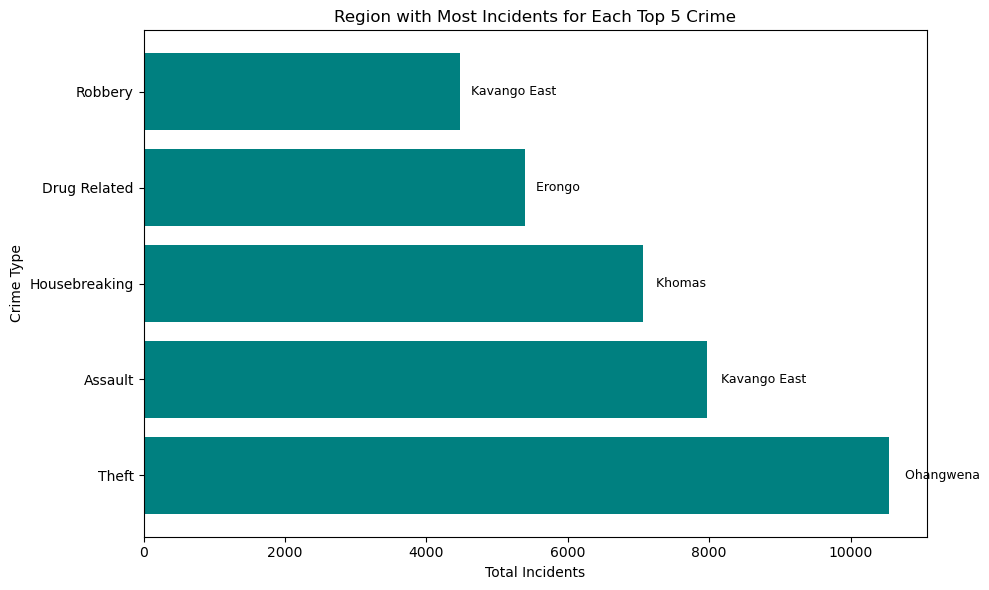

In [24]:
# Prepare data: for each top crime, get the top region and its count
top_crime_regions = []
for crime in top5_crimes:
    crime_df = df[df['CrimeType'] == crime]
    region_sum = crime_df.groupby('Region')['CrimeCount'].sum()
    top_region = region_sum.idxmax()
    top_count = region_sum.max()
    top_crime_regions.append({'Crime': crime, 'TopRegion': top_region, 'Incidents': top_count})

top_region_df = pd.DataFrame(top_crime_regions)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(top_region_df['Crime'], top_region_df['Incidents'], color='teal')
plt.xlabel('Total Incidents')
plt.ylabel('Crime Type')
plt.title('Region with Most Incidents for Each Top 5 Crime')
# Add region names as labels at the end of each bar
for i, (crime, region, val) in enumerate(zip(top_region_df['Crime'], top_region_df['TopRegion'], top_region_df['Incidents'])):
    plt.text(val + (val * 0.01), i, f'  {region}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_region_per_crime.png')
plt.show()

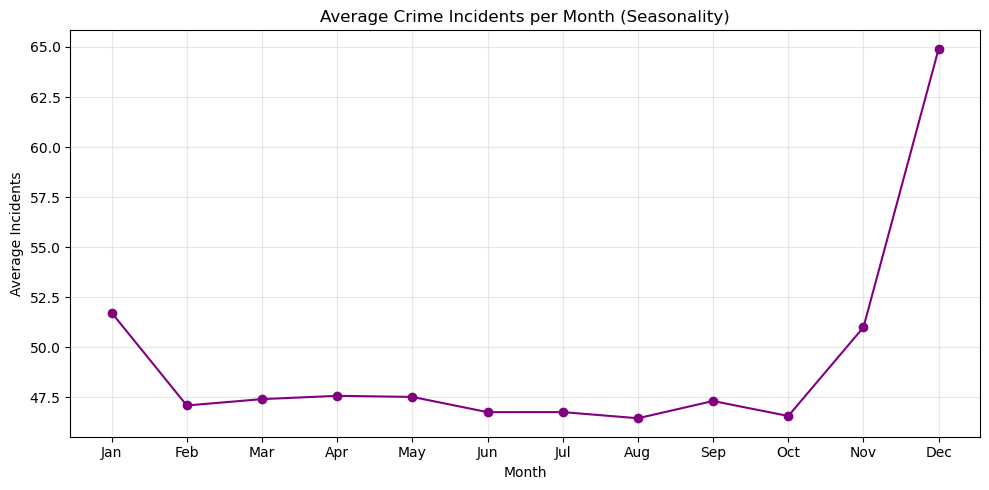

In [25]:
# Cell 8: Seasonal pattern (average crime by month)
monthly_avg = df.groupby('Month')['CrimeCount'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))
plt.plot(range(1,13), monthly_avg.values, marker='o', linestyle='-', color='purple')
plt.title('Average Crime Incidents per Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Incidents')
plt.xticks(range(1,13), months)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('seasonality.png')
plt.show()

C:\Users\VISTORINA\AppData\Local\Temp\ipykernel_14440\520960696.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '68889.59999999999' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  yearly_total[2025] = yearly_total[2025] * scale_factor


Note: 2025 data scaled from 5 months to full year estimate.


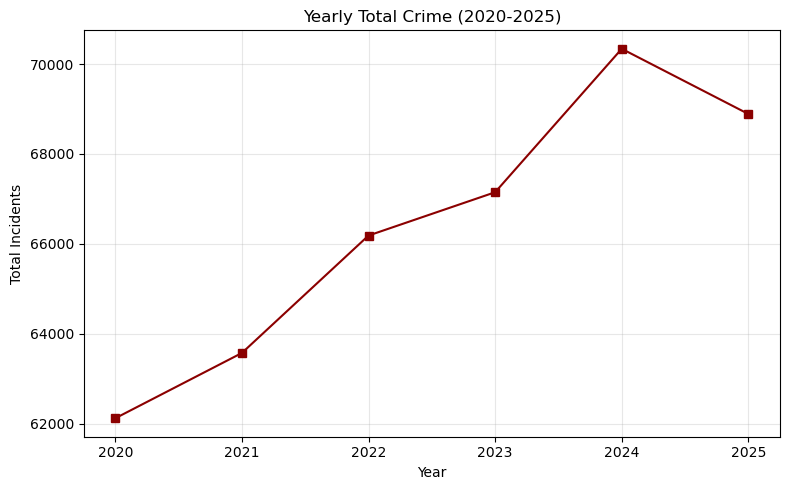

In [29]:
# Cell 9: Yearly trend (total crime per year)
yearly_total = df.groupby('Year')['CrimeCount'].sum()
# If 2025 is partial (only 5 months), scale to full year
if 2025 in yearly_total.index:
    months_in_2025 = df[df['Year'] == 2025]['Month'].nunique()  # should be 5
    if months_in_2025 < 12:
        scale_factor = 12 / months_in_2025
        yearly_total[2025] = yearly_total[2025] * scale_factor
        print(f"Note: 2025 data scaled from {months_in_2025} months to full year estimate.")
plt.figure(figsize=(8,5))
plt.plot(yearly_total.index, yearly_total.values, marker='s', linestyle='-', color='darkred')
plt.title('Yearly Total Crime (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Total Incidents')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('yearly_trend.png')
plt.show()